d:\Rakib\final\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.9.1+cu130
CUDA available : True
Selected device: cuda
GPU name       : NVIDIA GeForce RTX 5060 Ti
GPU count      : 1
Output folder  : C:\Users\User\Desktop\Brain Cancer\task4_ssl1_simclr
Total images : 4479
Total classes: 44


,path,label_name,label
0,C:\Users\User\Desktop\Brain Cancer\Astrocitoma...,Astrocitoma T1,0
1,C:\Users\User\Desktop\Brain Cancer\Astrocitoma...,Astrocitoma T1,0
2,C:\Users\User\Desktop\Brain Cancer\Astrocitoma...,Astrocitoma T1,0
3,C:\Users\User\Desktop\Brain Cancer\Astrocitoma...,Astrocitoma T1,0
4,C:\Users\User\Desktop\Brain Cancer\Astrocitoma...,Astrocitoma T1,0


Train size: 3628
Val size  : 403
Test size : 448

Running one-batch sanity check...
Batch shapes: torch.Size([16, 3, 160, 160]) torch.Size([16, 3, 160, 160])
First sample : C:\Users\User\Desktop\Brain Cancer\Tuberculoma T1\f132bfdf20476efa7b6c990990dec1_big_gallery.jpeg


C:\Users\User\AppData\Local\Temp\ipykernel_16644\213165995.py:334: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=AMP)


...

[Epoch 03/5] avg_ssl_loss=1.3717 | time=36.0s | lr=0.000104 | GPU mem: alloc=0.21GB reserved=0.42GB


C:\Users\User\AppData\Local\Temp\ipykernel_16644\213165995.py:438: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP):


[Epoch 04/5] avg_ssl_loss=1.1171 | time=35.7s | lr=0.000029 | GPU mem: alloc=0.21GB reserved=0.42GB


C:\Users\User\AppData\Local\Temp\ipykernel_16644\213165995.py:438: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP):


[Epoch 05/5] avg_ssl_loss=1.0244 | time=35.7s | lr=0.000000 | GPU mem: alloc=0.21GB reserved=0.42GB


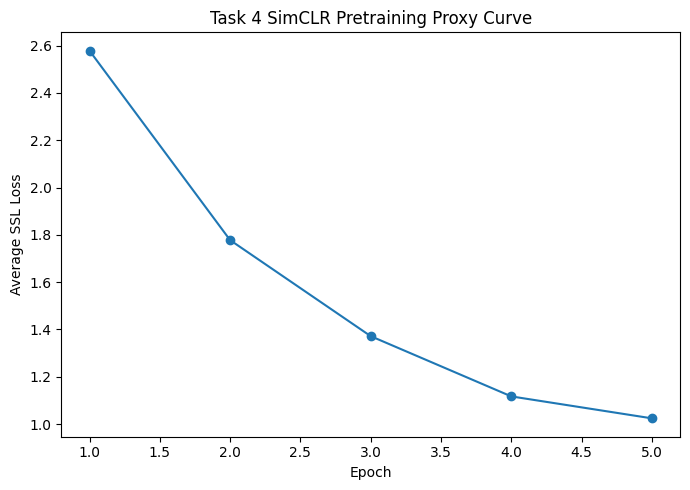


================ TASK 4 COMPLETE ================

Used local GPU: True
Best metric: {'name': 'avg_ssl_loss', 'value': 1.0243727190304646}
Frozen encoder saved to: C:\Users\User\Desktop\Brain Cancer\task4_ssl1_simclr\simclr_frozen_encoder.pth
Latest checkpoint saved to: C:\Users\User\Desktop\Brain Cancer\task4_ssl1_simclr\simclr_latest.pt
Best checkpoint saved to: C:\Users\User\Desktop\Brain Cancer\task4_ssl1_simclr\simclr_best.pt
Summary JSON: C:\Users\User\Desktop\Brain Cancer\task4_ssl1_simclr\task4_summary.json


,epoch,avg_ssl_loss,epoch_seconds,global_step_end,lr
0,1,2.578120,43.027395,226,0.000271
1,2,1.777569,36.112446,452,0.000196
2,3,1.371708,36.018518,678,0.000104
3,4,1.117106,35.682450,904,0.000029
4,5,1.024373,35.687526,1130,0.000000


In [1]:
# ============================================================
# TASK 4 ONLY — SSL-1 PRETRAINING (SimCLR)
# Smooth local VS Code / Windows / GPU-safe one-cell notebook
# ============================================================

import os
import sys
import json
import time
import random
import subprocess
import importlib.util
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Dict, Any

# ------------------------------------------------------------
# 0) Install missing package if needed
# ------------------------------------------------------------
def ensure_package(pkg_name: str, pip_name: str = None):
    pip_name = pip_name or pkg_name
    if importlib.util.find_spec(pkg_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])

ensure_package("timm", "timm==1.0.9")

# ------------------------------------------------------------
# 1) Imports
# ------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# 2) Config
# ------------------------------------------------------------
@dataclass
class CFG:
    DATA_DIR: str = r"C:\Users\User\Desktop\Brain Cancer"
    OUT_DIR: str = r"C:\Users\User\Desktop\Brain Cancer\task4_ssl1_simclr"

    seed: int = 42

    # split
    train_pct: int = 90
    test_pct: int = 10
    val_in_train: float = 0.10

    # image / loader
    img_size: int = 160          # safer first run
    batch_size_ssl: int = 16     # safer first run
    num_workers: int = 0         # IMPORTANT: safest for Windows notebook

    # SimCLR
    backbone: str = "resnet18"   # safer first run; after success change to resnet50
    proj_hidden: int = 512
    proj_dim: int = 128
    temperature: float = 0.2

    # training
    ssl_epochs: int = 5          # safer first run; later increase to 20/30
    ssl_lr: float = 3e-4
    weight_decay: float = 1e-4

    # logging / resume
    log_every_steps: int = 10
    resume_path: str = ""

    # reproducibility
    deterministic: bool = True

cfg = CFG()
os.makedirs(cfg.OUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# 3) Device / GPU check
# ------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP = torch.cuda.is_available()
PIN_MEMORY = torch.cuda.is_available()

print("=" * 70)
print("PyTorch version:", torch.__version__)
print("CUDA available :", torch.cuda.is_available())
print("Selected device:", DEVICE)
if torch.cuda.is_available():
    print("GPU name       :", torch.cuda.get_device_name(0))
    print("GPU count      :", torch.cuda.device_count())
print("Output folder  :", cfg.OUT_DIR)
print("=" * 70)

# ------------------------------------------------------------
# 4) Reproducibility
# ------------------------------------------------------------
def seed_everything(seed: int, deterministic: bool = True):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True

def get_rng_state() -> Dict[str, Any]:
    state = {
        "python_random_state": random.getstate(),
        "numpy_random_state": np.random.get_state(),
        "torch_rng_state": torch.get_rng_state().cpu(),
    }
    if torch.cuda.is_available():
        state["torch_cuda_rng_state_all"] = [s.cpu() for s in torch.cuda.get_rng_state_all()]
    return state

def set_rng_state(state: Dict[str, Any]):
    random.setstate(state["python_random_state"])
    np.random.set_state(state["numpy_random_state"])
    torch.set_rng_state(state["torch_rng_state"])
    if torch.cuda.is_available() and "torch_cuda_rng_state_all" in state:
        torch.cuda.set_rng_state_all(state["torch_cuda_rng_state_all"])

seed_everything(cfg.seed, cfg.deterministic)

# ------------------------------------------------------------
# 5) Scan dataset
# ------------------------------------------------------------
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

def scan_dataset(root: str) -> pd.DataFrame:
    rows = []
    root = Path(root)
    for p in root.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            rows.append((str(p), p.parent.name))
    return pd.DataFrame(rows, columns=["path", "label_name"])

df = scan_dataset(cfg.DATA_DIR)
assert len(df) > 0, f"No images found under {cfg.DATA_DIR}"

label_names = sorted(df["label_name"].unique().tolist())
label_to_idx = {name: i for i, name in enumerate(label_names)}
idx_to_label = {i: name for name, i in label_to_idx.items()}
df["label"] = df["label_name"].map(label_to_idx).astype(int)
num_classes = len(label_names)

print("Total images :", len(df))
print("Total classes:", num_classes)
display(df.head())

# ------------------------------------------------------------
# 6) Train / val / test split
# Task 4 trains only on TRAIN split, but saves full split manifest
# ------------------------------------------------------------
def make_split(df_all: pd.DataFrame, seed: int):
    test_ratio = cfg.test_pct / 100.0
    train_all, test_df = train_test_split(
        df_all,
        test_size=test_ratio,
        random_state=seed,
        stratify=df_all["label"]
    )
    val_df, train_df = train_test_split(
        train_all,
        test_size=(1 - cfg.val_in_train),
        random_state=seed,
        stratify=train_all["label"]
    )
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)

train_df, val_df, test_df = make_split(df, cfg.seed)

print("Train size:", len(train_df))
print("Val size  :", len(val_df))
print("Test size :", len(test_df))

augmentation_recipe = {
    "RandomResizedCrop": f"size={cfg.img_size}, scale=(0.5,1.0)",
    "RandomHorizontalFlip": "p=0.5",
    "ColorJitter": "0.4,0.4,0.4,0.1 with p=0.8",
    "RandomGrayscale": "p=0.2",
    "GaussianBlur": "kernel_size=23, sigma=(0.1,2.0)",
    "Normalize": "ImageNet mean/std"
}

split_manifest = {
    "seed": cfg.seed,
    "split": {
        "train_pct": cfg.train_pct,
        "test_pct": cfg.test_pct,
        "val_in_train": cfg.val_in_train
    },
    "counts": {
        "all": int(len(df)),
        "train": int(len(train_df)),
        "val": int(len(val_df)),
        "test": int(len(test_df)),
        "classes": int(num_classes)
    },
    "label_to_idx": label_to_idx,
    "idx_to_label": idx_to_label,
    "train_paths": train_df["path"].tolist(),
    "val_paths": val_df["path"].tolist(),
    "test_paths": test_df["path"].tolist(),
    "augmentation_recipe": augmentation_recipe
}

manifest_path = os.path.join(cfg.OUT_DIR, "split_manifest.json")
with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(split_manifest, f, indent=2)

# ------------------------------------------------------------
# 7) Transforms
# ------------------------------------------------------------
normalize = transforms.Normalize(
    mean=(0.485, 0.456, 0.406),
    std=(0.229, 0.224, 0.225)
)

ssl_transform = transforms.Compose([
    transforms.RandomResizedCrop(cfg.img_size, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.GaussianBlur(kernel_size=23, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    normalize
])

# ------------------------------------------------------------
# 8) Dataset / DataLoader
# IMPORTANT: num_workers=0 to avoid Windows notebook freeze
# ------------------------------------------------------------
class SSLPairDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform):
        self.paths = df["path"].tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        p = self.paths[idx]
        img = Image.open(p).convert("RGB")
        x1 = self.transform(img)
        x2 = self.transform(img)
        return x1, x2, p

ssl_train_ds = SSLPairDataset(train_df, ssl_transform)

ssl_train_loader = DataLoader(
    ssl_train_ds,
    batch_size=cfg.batch_size_ssl,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=PIN_MEMORY,
    drop_last=True
)

# ------------------------------------------------------------
# 9) Quick sanity check BEFORE training
# ------------------------------------------------------------
print("\nRunning one-batch sanity check...")
x1_chk, x2_chk, p_chk = next(iter(ssl_train_loader))
print("Batch shapes:", x1_chk.shape, x2_chk.shape)
print("First sample :", p_chk[0])

# ------------------------------------------------------------
# 10) SimCLR model
# ------------------------------------------------------------
def get_encoder(backbone_name: str):
    encoder = timm.create_model(
        backbone_name,
        pretrained=False,
        num_classes=0,
        global_pool="avg"
    )
    feat_dim = encoder.num_features
    return encoder, feat_dim

class ProjectionHead(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x):
        return self.net(x)

class SimCLR(nn.Module):
    def __init__(self, backbone: str, proj_hidden: int, proj_dim: int):
        super().__init__()
        self.encoder, feat_dim = get_encoder(backbone)
        self.proj = ProjectionHead(feat_dim, proj_hidden, proj_dim)

    def forward(self, x):
        h = self.encoder(x)
        z = self.proj(h)
        z = F.normalize(z, dim=1)
        return h, z

def nt_xent_loss(z1: torch.Tensor, z2: torch.Tensor, temperature: float = 0.2):
    B = z1.size(0)
    z = torch.cat([z1, z2], dim=0)

    # float32 similarity for safety under AMP
    sim = torch.matmul(z.float(), z.float().T) / temperature

    mask = torch.eye(2 * B, device=z.device, dtype=torch.bool)
    sim = sim.masked_fill(mask, float("-inf"))

    pos = torch.cat([torch.diag(sim, B), torch.diag(sim, -B)], dim=0)
    loss = -pos + torch.logsumexp(sim, dim=1)
    return loss.mean()

model = SimCLR(cfg.backbone, cfg.proj_hidden, cfg.proj_dim).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.ssl_lr, weight_decay=cfg.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.ssl_epochs)
scaler = torch.cuda.amp.GradScaler(enabled=AMP)

# model sanity check on GPU
with torch.no_grad():
    x_gpu = x1_chk.to(DEVICE)
    h_chk, z_chk = model(x_gpu)
    print("Encoder output shape   :", h_chk.shape)
    print("Projection output shape:", z_chk.shape)

# ------------------------------------------------------------
# 11) Checkpointing and logging
# ------------------------------------------------------------
latest_ckpt_path = os.path.join(cfg.OUT_DIR, "simclr_latest.pt")
best_ckpt_path = os.path.join(cfg.OUT_DIR, "simclr_best.pt")
frozen_encoder_path = os.path.join(cfg.OUT_DIR, "simclr_frozen_encoder.pth")
full_model_path = os.path.join(cfg.OUT_DIR, "simclr_full_model_final.pt")

csv_log_path = os.path.join(cfg.OUT_DIR, "simclr_epoch_log.csv")
jsonl_log_path = os.path.join(cfg.OUT_DIR, "simclr_run_log.jsonl")
curve_png_path = os.path.join(cfg.OUT_DIR, "simclr_pretraining_curve.png")
summary_json_path = os.path.join(cfg.OUT_DIR, "task4_summary.json")

def append_jsonl(path: str, obj: Dict[str, Any]):
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(obj) + "\n")

def save_checkpoint(path, epoch, global_step, best_metric, model, optimizer, scheduler, scaler, split_manifest_path, cfg_dict):
    ckpt = {
        "epoch": epoch,
        "global_step": global_step,
        "best_metric": best_metric,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict() if scheduler is not None else None,
        "scaler_state": scaler.state_dict() if scaler is not None else None,
        "rng_state": get_rng_state(),
        "split_manifest_path": split_manifest_path,
        "cfg": cfg_dict,
        "ssl_method": "SimCLR",
        "ssl_specific_state": {
            "temperature": cfg.temperature,
            "projector_included": True
        }
    }
    torch.save(ckpt, path)

def load_checkpoint(path, model, optimizer=None, scheduler=None, scaler=None):
    ckpt = torch.load(path, map_location="cpu")
    model.load_state_dict(ckpt["model_state"], strict=True)
    if optimizer is not None and ckpt.get("optimizer_state") is not None:
        optimizer.load_state_dict(ckpt["optimizer_state"])
    if scheduler is not None and ckpt.get("scheduler_state") is not None:
        scheduler.load_state_dict(ckpt["scheduler_state"])
    if scaler is not None and ckpt.get("scaler_state") is not None:
        scaler.load_state_dict(ckpt["scaler_state"])
    if ckpt.get("rng_state") is not None:
        set_rng_state(ckpt["rng_state"])
    return ckpt

if not os.path.exists(csv_log_path):
    pd.DataFrame(columns=["epoch", "avg_ssl_loss", "epoch_seconds", "global_step_end", "lr"]).to_csv(csv_log_path, index=False)

start_epoch = 0
global_step = 0
best_metric = {"name": "avg_ssl_loss", "value": float("inf")}

resume_candidate = None
if cfg.resume_path and os.path.exists(cfg.resume_path):
    resume_candidate = cfg.resume_path
elif os.path.exists(latest_ckpt_path):
    resume_candidate = latest_ckpt_path

if resume_candidate:
    ckpt = load_checkpoint(resume_candidate, model, optimizer, scheduler, scaler)
    start_epoch = int(ckpt["epoch"]) + 1
    global_step = int(ckpt.get("global_step", 0))
    best_metric = ckpt.get("best_metric", best_metric)
    print(f"Resumed from: {resume_candidate}")
else:
    print("Starting fresh run.")

# ------------------------------------------------------------
# 12) Training loop
# ------------------------------------------------------------
epoch_history = []
run_start = time.time()

if torch.cuda.is_available():
    warmup = torch.randn(4, 3, cfg.img_size, cfg.img_size, device=DEVICE)
    with torch.no_grad():
        _ = model.encoder(warmup)
    torch.cuda.synchronize()

for epoch in range(start_epoch, cfg.ssl_epochs):
    t0 = time.time()
    model.train()
    step_losses = []

    for batch_idx, (x1, x2, _) in enumerate(ssl_train_loader):
        x1 = x1.to(DEVICE, non_blocking=True)
        x2 = x2.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=AMP):
            _, z1 = model(x1)
            _, z2 = model(x2)

        # outside autocast for numerical stability
        loss = nt_xent_loss(z1, z2, cfg.temperature)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        global_step += 1
        loss_value = float(loss.item())
        step_losses.append(loss_value)

        if (global_step % cfg.log_every_steps) == 0:
            append_jsonl(jsonl_log_path, {
                "event": "step",
                "epoch": int(epoch + 1),
                "step_in_epoch": int(batch_idx + 1),
                "global_step": int(global_step),
                "ssl_loss": loss_value,
                "lr": float(optimizer.param_groups[0]["lr"])
            })

    scheduler.step()

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    epoch_seconds = time.time() - t0
    avg_ssl_loss = float(np.mean(step_losses)) if step_losses else float("nan")
    lr_now = float(optimizer.param_groups[0]["lr"])

    epoch_row = {
        "epoch": int(epoch + 1),
        "avg_ssl_loss": avg_ssl_loss,
        "epoch_seconds": float(epoch_seconds),
        "global_step_end": int(global_step),
        "lr": lr_now
    }
    epoch_history.append(epoch_row)

    prev = pd.read_csv(csv_log_path)
    prev = pd.concat([prev, pd.DataFrame([epoch_row])], ignore_index=True)
    prev.to_csv(csv_log_path, index=False)

    append_jsonl(jsonl_log_path, {"event": "epoch", **epoch_row})

    save_checkpoint(
        latest_ckpt_path, epoch, global_step, best_metric, model,
        optimizer, scheduler, scaler, manifest_path, asdict(cfg)
    )

    if avg_ssl_loss < float(best_metric["value"]):
        best_metric = {"name": "avg_ssl_loss", "value": avg_ssl_loss}
        save_checkpoint(
            best_ckpt_path, epoch, global_step, best_metric, model,
            optimizer, scheduler, scaler, manifest_path, asdict(cfg)
        )

    gpu_mem = ""
    if torch.cuda.is_available():
        alloc = torch.cuda.memory_allocated() / (1024 ** 3)
        reserv = torch.cuda.memory_reserved() / (1024 ** 3)
        gpu_mem = f" | GPU mem: alloc={alloc:.2f}GB reserved={reserv:.2f}GB"

    print(
        f"[Epoch {epoch+1:02d}/{cfg.ssl_epochs}] "
        f"avg_ssl_loss={avg_ssl_loss:.4f} | "
        f"time={epoch_seconds:.1f}s | "
        f"lr={lr_now:.6f}{gpu_mem}"
    )

total_train_seconds = time.time() - run_start

# ------------------------------------------------------------
# 13) Save outputs
# ------------------------------------------------------------
torch.save(model.encoder.state_dict(), frozen_encoder_path)

torch.save({
    "model_state": model.state_dict(),
    "encoder_state": model.encoder.state_dict(),
    "cfg": asdict(cfg),
    "split_manifest_path": manifest_path,
    "best_metric": best_metric
}, full_model_path)

epoch_df = pd.read_csv(csv_log_path)

plt.figure(figsize=(7, 5))
plt.plot(epoch_df["epoch"], epoch_df["avg_ssl_loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Average SSL Loss")
plt.title("Task 4 SimCLR Pretraining Proxy Curve")
plt.tight_layout()
plt.savefig(curve_png_path, dpi=200)
plt.show()

summary = {
    "task": "Task 4",
    "ssl_method": "SimCLR",
    "backbone": cfg.backbone,
    "device": str(DEVICE),
    "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "amp_enabled": AMP,
    "used_local_gpu": bool(torch.cuda.is_available()),
    "total_train_seconds": total_train_seconds,
    "epochs_completed": int(len(epoch_df)),
    "best_metric": best_metric,
    "artifacts": {
        "split_manifest": manifest_path,
        "epoch_csv_log": csv_log_path,
        "jsonl_log": jsonl_log_path,
        "latest_checkpoint": latest_ckpt_path,
        "best_checkpoint": best_ckpt_path,
        "frozen_encoder_weights": frozen_encoder_path,
        "full_final_model": full_model_path,
        "proxy_curve_png": curve_png_path
    },
    "augmentation_recipe": augmentation_recipe
}

with open(summary_json_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("\n================ TASK 4 COMPLETE ================\n")
print("Used local GPU:", torch.cuda.is_available())
print("Best metric:", best_metric)
print("Frozen encoder saved to:", frozen_encoder_path)
print("Latest checkpoint saved to:", latest_ckpt_path)
print("Best checkpoint saved to:", best_ckpt_path)
print("Summary JSON:", summary_json_path)
display(epoch_df.tail())